# 1. Introduction

**Contexte et motivation**

L’espérance de vie diffère systématiquement entre les femmes et les hommes, mais l’ampleur de cet écart varie fortement selon les pays et dans le temps. Comprendre les déterminants de cet écart constitue un enjeu important pour l’analyse des inégalités de santé et l’évaluation des politiques publiques. Dans ce travail, nous nous intéressons à **l’écart d’espérance de vie entre femmes et hommes (LE_WMGap)**, et, en extension, à **l’écart d’espérance de vie en bonne santé (HALE_WMGap)**, sur un panel de 26 pays observés entre 2000 et 2021.

**Objectifs**

L’étude poursuit deux objectifs complémentaires. Premièrement, nous cherchons à expliquer et prédire l’évolution de l’écart femmes–hommes à partir d’un ensemble d’indicateurs socio-économiques (PIB par habitant, indice de Gini, IDH, chômage), environnementaux (CO₂ par habitant), sanitaires (mortalité infantile, mortalité adulte, mortalité prématurée), ainsi que des variables liées au système de santé, dont les dépenses de santé en proportion du PIB et les dépenses publiques de santé (DPGS). Deuxièmement, nous mobilisons des méthodes non supervisées pour regrouper les pays en profils homogènes en fonction de leurs caractéristiques sanitaires et économiques.

**Approche méthodologique**

Notre démarche combine une analyse exploratoire des données (EDA) et des méthodes de Machine Learning adaptées aux données. Compte tenu de la structure panel (pays–années), une attention particulière est portée à la validation temporelle afin d’éviter toute fuite d’information : les modèles sont entraînés sur une période passée et évalués sur une période plus récente. Plusieurs modèles sont comparés : une régression linéaire de référence, des régressions pénalisées (Ridge/Lasso/ElasticNet) pour gérer la multicolinéarité et la sélection de variables, ainsi que des modèles non linéaires (forêts aléatoires, gradient boosting) capables de capturer des relations complexes. Les performances sont mesurées à l’aide de métriques standard de régression (MAE, RMSE, R²), et les résultats sont interprétés à travers l’importance des variables et la cohérence avec les déterminants attendus.


# 2. Importation des librairies 

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("DataML.csv", sep=";")
display(df.head())

,Années,Pays,Code_Pays,Statut,LE_femmes,LE_hommes,HALE_femmes,HALE_hommes,LE_60_femmes,LE_60_hommes,...,Pop_60_64_femmes,Pop_60_64_hommes,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes
0,2000,Brésil,BRA,Developing,72.960,66.347,62.737055,59.172181,19.4932,16.5902,...,2.719295,2.489838,2.271030,1.844012,1.713595,1.295986,1.046500,0.751321,0.822965,0.551714
1,2001,Brésil,BRA,Developing,73.400,66.699,62.963842,59.389943,19.6649,16.7358,...,2.744890,2.543488,2.277358,1.865670,1.751965,1.317702,1.092544,0.775602,0.855875,0.569281
2,2002,Brésil,BRA,Developing,73.843,67.085,63.091429,59.578401,19.8502,16.9187,...,2.776097,2.595700,2.285800,1.896928,1.785950,1.338731,1.139355,0.800088,0.893839,0.589901
3,2003,Brésil,BRA,Developing,74.337,67.558,63.265723,59.785036,20.1474,17.2464,...,2.812252,2.646808,2.299738,1.937946,1.814942,1.359915,1.186709,0.825261,0.937720,0.613985
4,2004,Brésil,BRA,Developing,74.824,68.019,63.375544,59.963533,20.4626,17.5307,...,2.854592,2.697717,2.322712,1.989437,1.839327,1.382518,1.233853,0.850931,0.987538,0.641215


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 68 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Années               572 non-null    int64  
 1   Pays                 572 non-null    object 
 2   Code_Pays            572 non-null    object 
 3   Statut               572 non-null    object 
 4   LE_femmes            572 non-null    float64
 5   LE_hommes            572 non-null    float64
 6   HALE_femmes          572 non-null    float64
 7   HALE_hommes          572 non-null    float64
 8   LE_60_femmes         572 non-null    float64
 9   LE_60_hommes         572 non-null    float64
 10  LE_WMGap             572 non-null    float64
 11  LE_WMGap_60          572 non-null    float64
 12  HALE_WMGap           572 non-null    float64
 13  PIB_habitant         572 non-null    float64
 14  Dep_sante_PIB        572 non-null    float64
 15  Gini                 572 non-null    flo

In [4]:
df.describe()

,Années,LE_femmes,LE_hommes,HALE_femmes,HALE_hommes,LE_60_femmes,LE_60_hommes,LE_WMGap,LE_WMGap_60,HALE_WMGap,...,Pop_60_64_femmes,Pop_60_64_hommes,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,...,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,2010.500000,75.352997,70.505528,64.770330,62.813828,21.931697,18.861276,4.847469,3.070421,1.956502,...,4.100952,3.911673,3.465301,3.165213,2.859369,2.444706,2.259147,1.735875,3.090448,1.775145
std,6.349842,9.650628,8.696856,7.052813,6.898824,3.931937,3.073358,2.139459,1.401938,1.765481,...,1.705904,1.709338,1.642729,1.583627,1.563303,1.408052,1.432589,1.132734,2.579333,1.458811
min,2000.000000,48.038000,46.255000,45.388742,43.969850,14.569800,12.729600,0.317000,0.256400,-1.265216,...,1.019648,1.234781,0.827013,0.937715,0.626860,0.644322,0.404273,0.376597,0.260939,0.203760
25%,2005.000000,70.460750,65.630500,61.057387,59.082471,18.746775,16.027950,3.700000,1.915250,0.837623,...,2.638854,2.408037,2.109816,1.842567,1.611113,1.335284,1.070768,0.812097,0.911188,0.614880
50%,2010.500000,77.908000,72.276500,66.853792,64.928973,22.093700,19.319050,4.700000,2.997850,1.673186,...,3.905384,3.621385,2.992890,2.755513,2.420535,2.032369,1.739667,1.328485,1.978949,1.166204
75%,2016.000000,83.000000,77.740000,70.015395,68.417626,25.271875,21.673625,6.100000,4.035250,2.758407,...,5.654512,5.481567,4.883435,4.433320,4.173269,3.589077,3.609562,2.796311,5.384905,2.855238
max,2021.000000,87.710000,82.100000,75.113417,72.102035,29.442000,24.232900,13.550000,5.695700,10.111880,...,8.171060,8.309816,8.048057,7.969285,7.859706,7.445625,6.153490,5.320707,11.913565,7.296433


In [5]:
print(df.isnull().sum())

Années                0
Pays                  0
Code_Pays             0
Statut                0
LE_femmes             0
                     ..
Pop_70_74_hommes      0
Pop_75_79_femmes      0
Pop_75_79_hommes      0
Pop_80_plus_femmes    0
Pop_80_plus_hommes    0
Length: 68, dtype: int64


In [6]:
df.columns

Index(['Années', 'Pays', 'Code_Pays', 'Statut', 'LE_femmes', 'LE_hommes',
       'HALE_femmes', 'HALE_hommes', 'LE_60_femmes', 'LE_60_hommes',
       'LE_WMGap', 'LE_WMGap_60', 'HALE_WMGap', 'PIB_habitant',
       'Dep_sante_PIB', 'Gini', 'DPGS', 'IDH', 'Mort_adultes_hommes',
       'Mort_adultes_femmes', 'Mort_inf_filles', 'Mort_inf_garçons',
       'Mort_prem_F', 'Mort_prem_H', 'Chomage_femmes', 'Chomage_hommes',
       'CO2_habitant', 'VIH_SIDA', 'Cancer_thyroïde', 'Cancer_Estomac',
       'Cancer_Utérus', 'Cancer_Foie', 'Cancer_Sein', 'Cancer_Testicule',
       'Pop_0_4_filles', 'Pop_0_4_garçons', 'Pop_5_9_filles',
       'Pop_5_9_garçons', 'Pop_10_14_filles', 'Pop_10_14_garçons',
       'Pop_15_19_filles', 'Pop_15_19_garçons', 'Pop_20_24_femmes',
       'Pop_20_24_hommes', 'Pop_25_29_femmes', 'Pop_25_29_hommes',
       'Pop_30_34_femmes', 'Pop_30_34_hommes', 'Pop_35_39_femmes',
       'Pop_35_39_hommes', 'Pop_40_44_femmes', 'Pop_40_44_hommes',
       'Pop_45_49_femmes', 'Pop_45_49

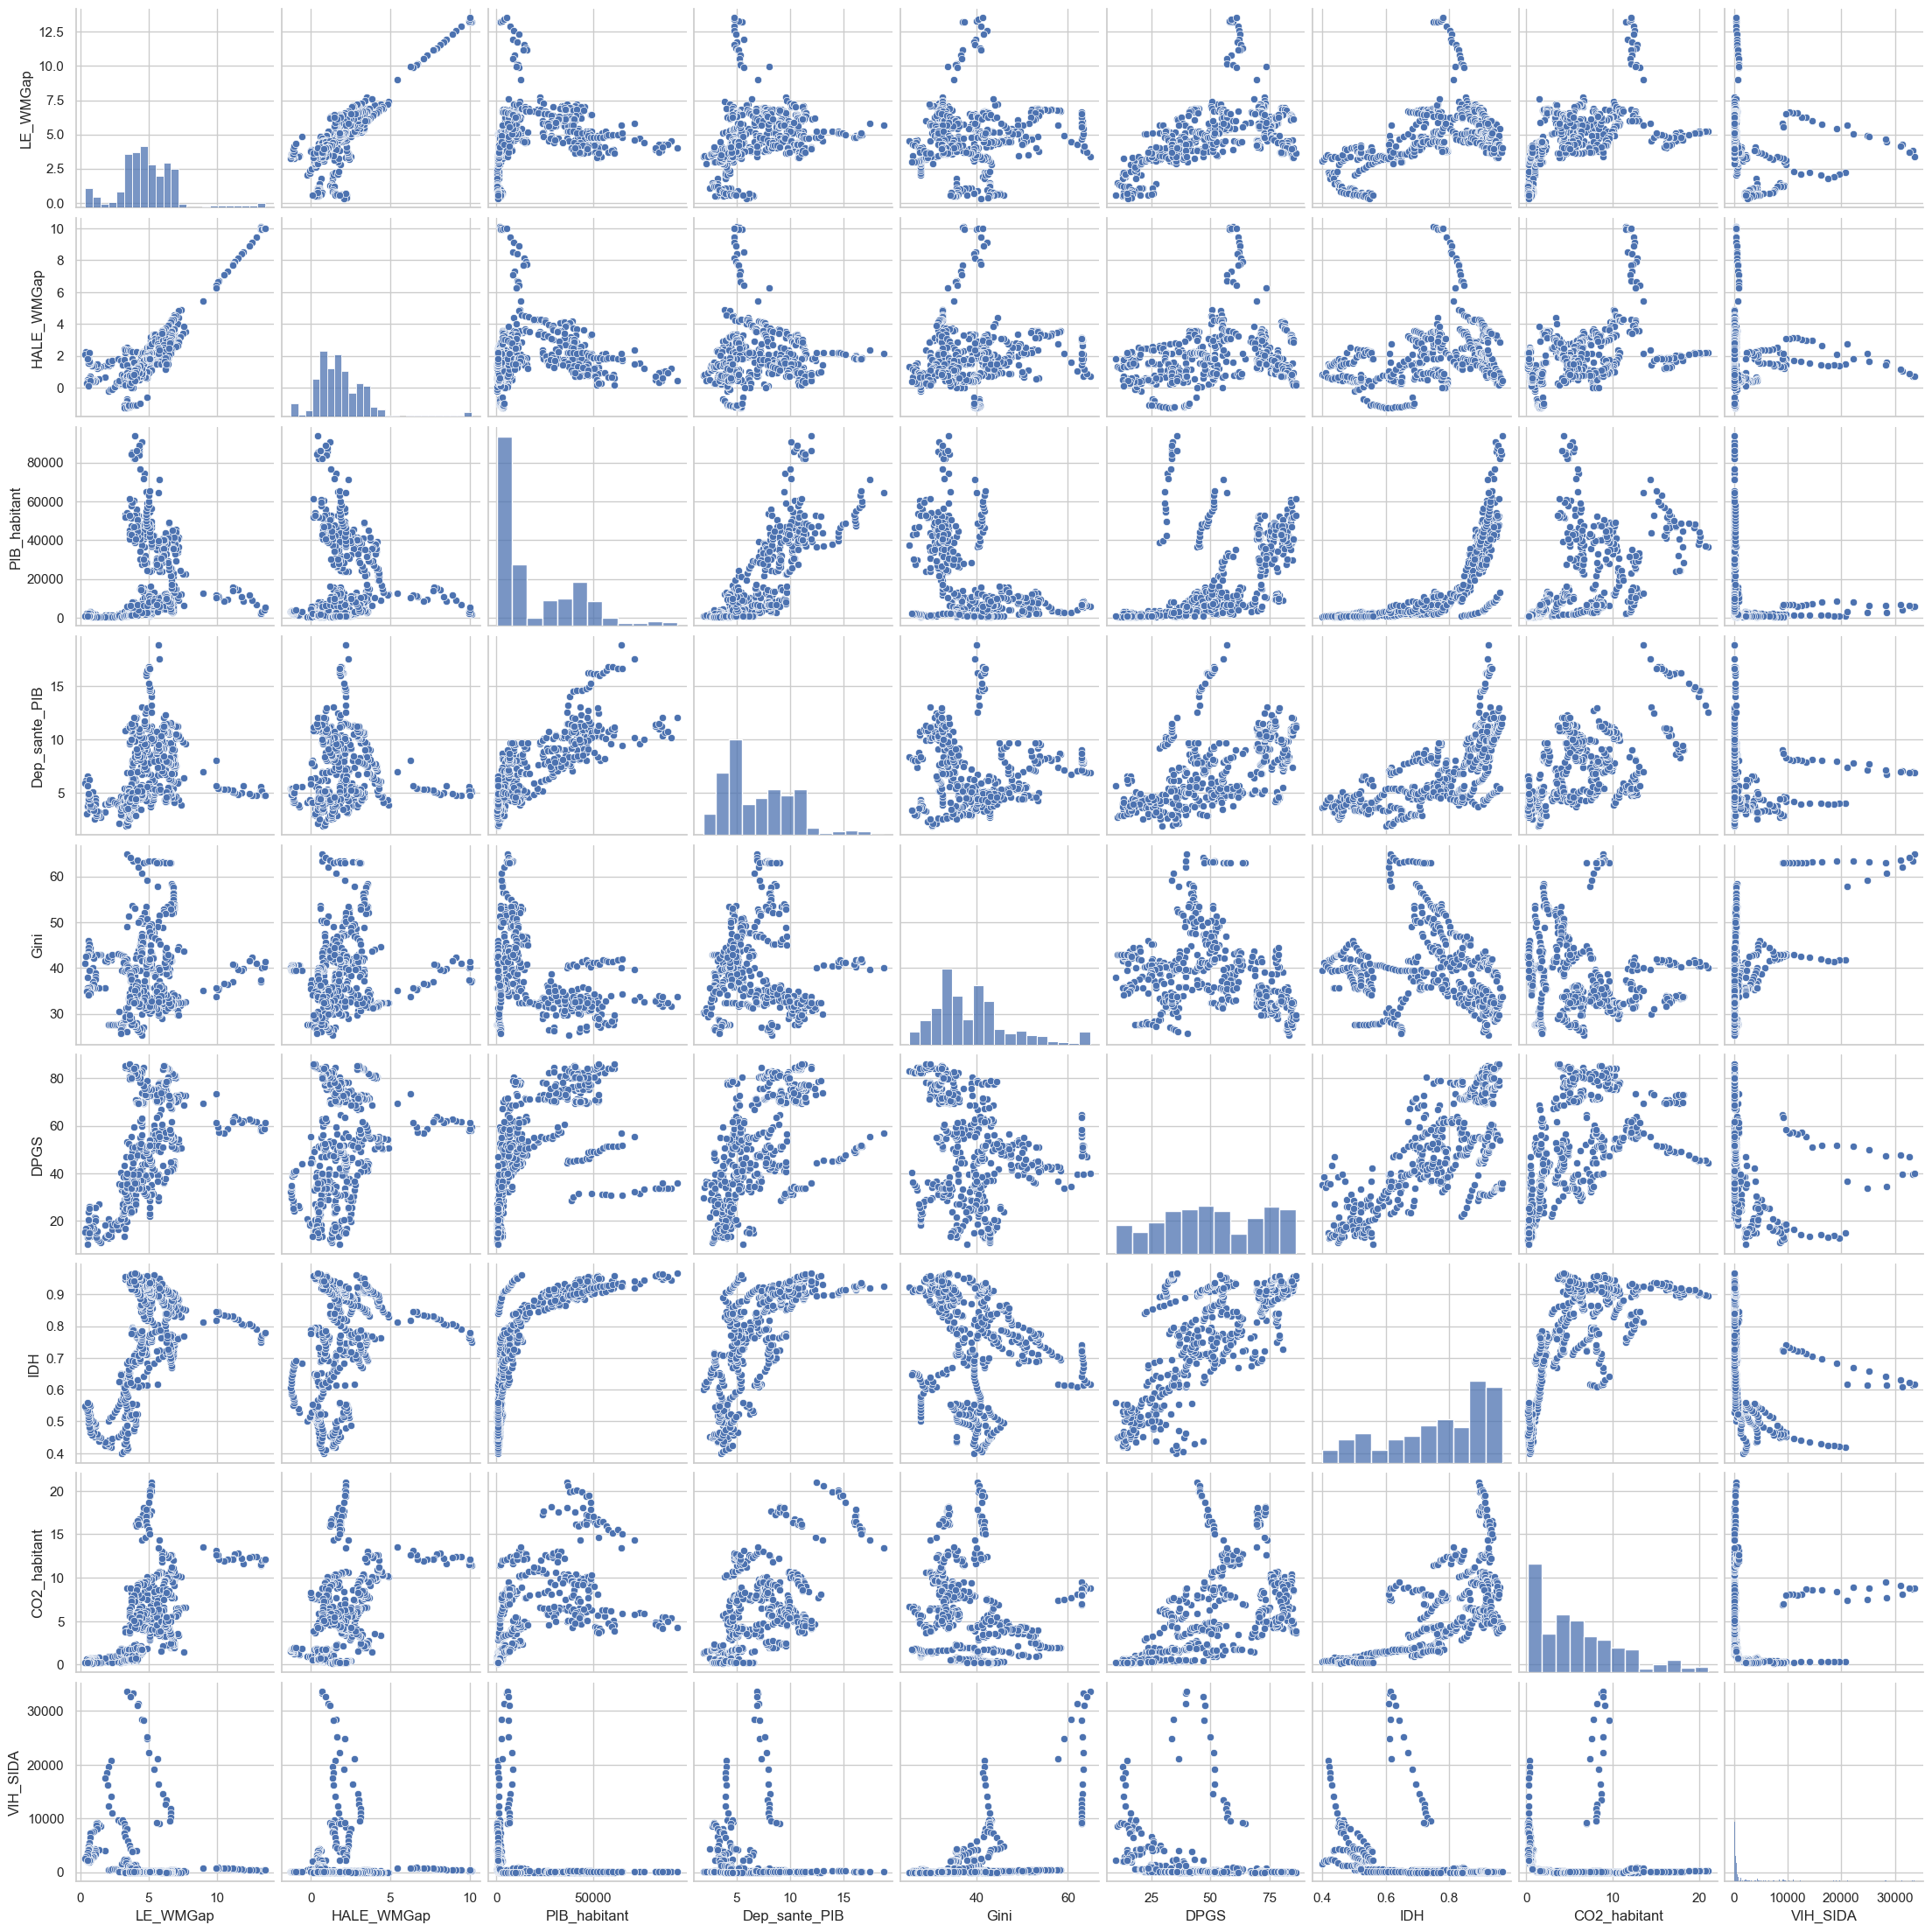

In [7]:
variables = ['LE_WMGap', 'HALE_WMGap', 'PIB_habitant',
       'Dep_sante_PIB', 'Gini', 'DPGS', 'IDH', 'CO2_habitant', 'VIH_SIDA']

sns.pairplot(df[variables].dropna())
plt.show()

# 3. Contrôle qualité (doublons, Valeurs manquantes)

In [8]:
dup = df.duplicated(subset=["Pays", "Années"]).sum()
print("Doublons (Pays, Années):", dup)

Doublons (Pays, Années): 0


In [9]:
!pip install missingno

In [10]:
def checkMissingValue(df):
    columns = df.columns.values
    print(f'Total rows: {len(df[columns[0]])}\n')
    
    for column in columns:
        print(f'Missing values: {df[column].isnull().sum()} \t Column Name: {column}')

In [11]:
checkMissingValue(df)

Total rows: 572

Missing values: 0 	 Column Name: Années
Missing values: 0 	 Column Name: Pays
Missing values: 0 	 Column Name: Code_Pays
Missing values: 0 	 Column Name: Statut
Missing values: 0 	 Column Name: LE_femmes
Missing values: 0 	 Column Name: LE_hommes
Missing values: 0 	 Column Name: HALE_femmes
Missing values: 0 	 Column Name: HALE_hommes
Missing values: 0 	 Column Name: LE_60_femmes
Missing values: 0 	 Column Name: LE_60_hommes
Missing values: 0 	 Column Name: LE_WMGap
Missing values: 0 	 Column Name: LE_WMGap_60
Missing values: 0 	 Column Name: HALE_WMGap
Missing values: 0 	 Column Name: PIB_habitant
Missing values: 0 	 Column Name: Dep_sante_PIB
Missing values: 0 	 Column Name: Gini
Missing values: 0 	 Column Name: DPGS
Missing values: 0 	 Column Name: IDH
Missing values: 0 	 Column Name: Mort_adultes_hommes
Missing values: 0 	 Column Name: Mort_adultes_femmes
Missing values: 0 	 Column Name: Mort_inf_filles
Missing values: 0 	 Column Name: Mort_inf_garçons
Missing valu

<Axes: >

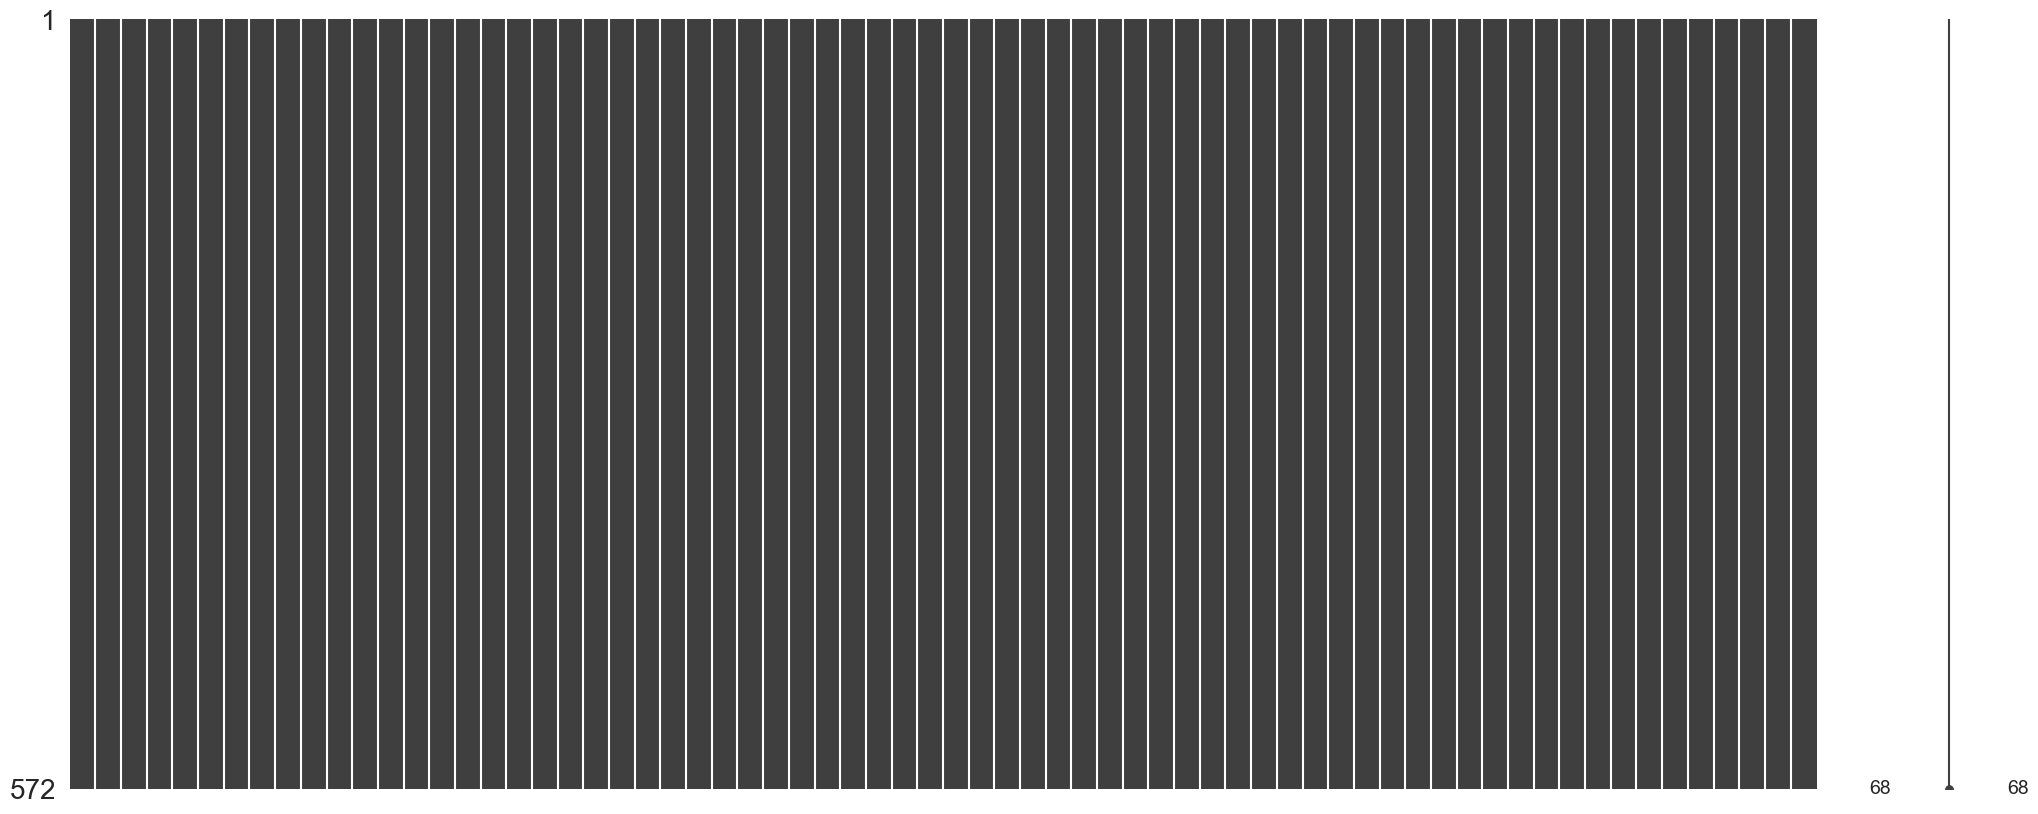

In [12]:
import missingno as msno
msno.matrix(df)

<Axes: >

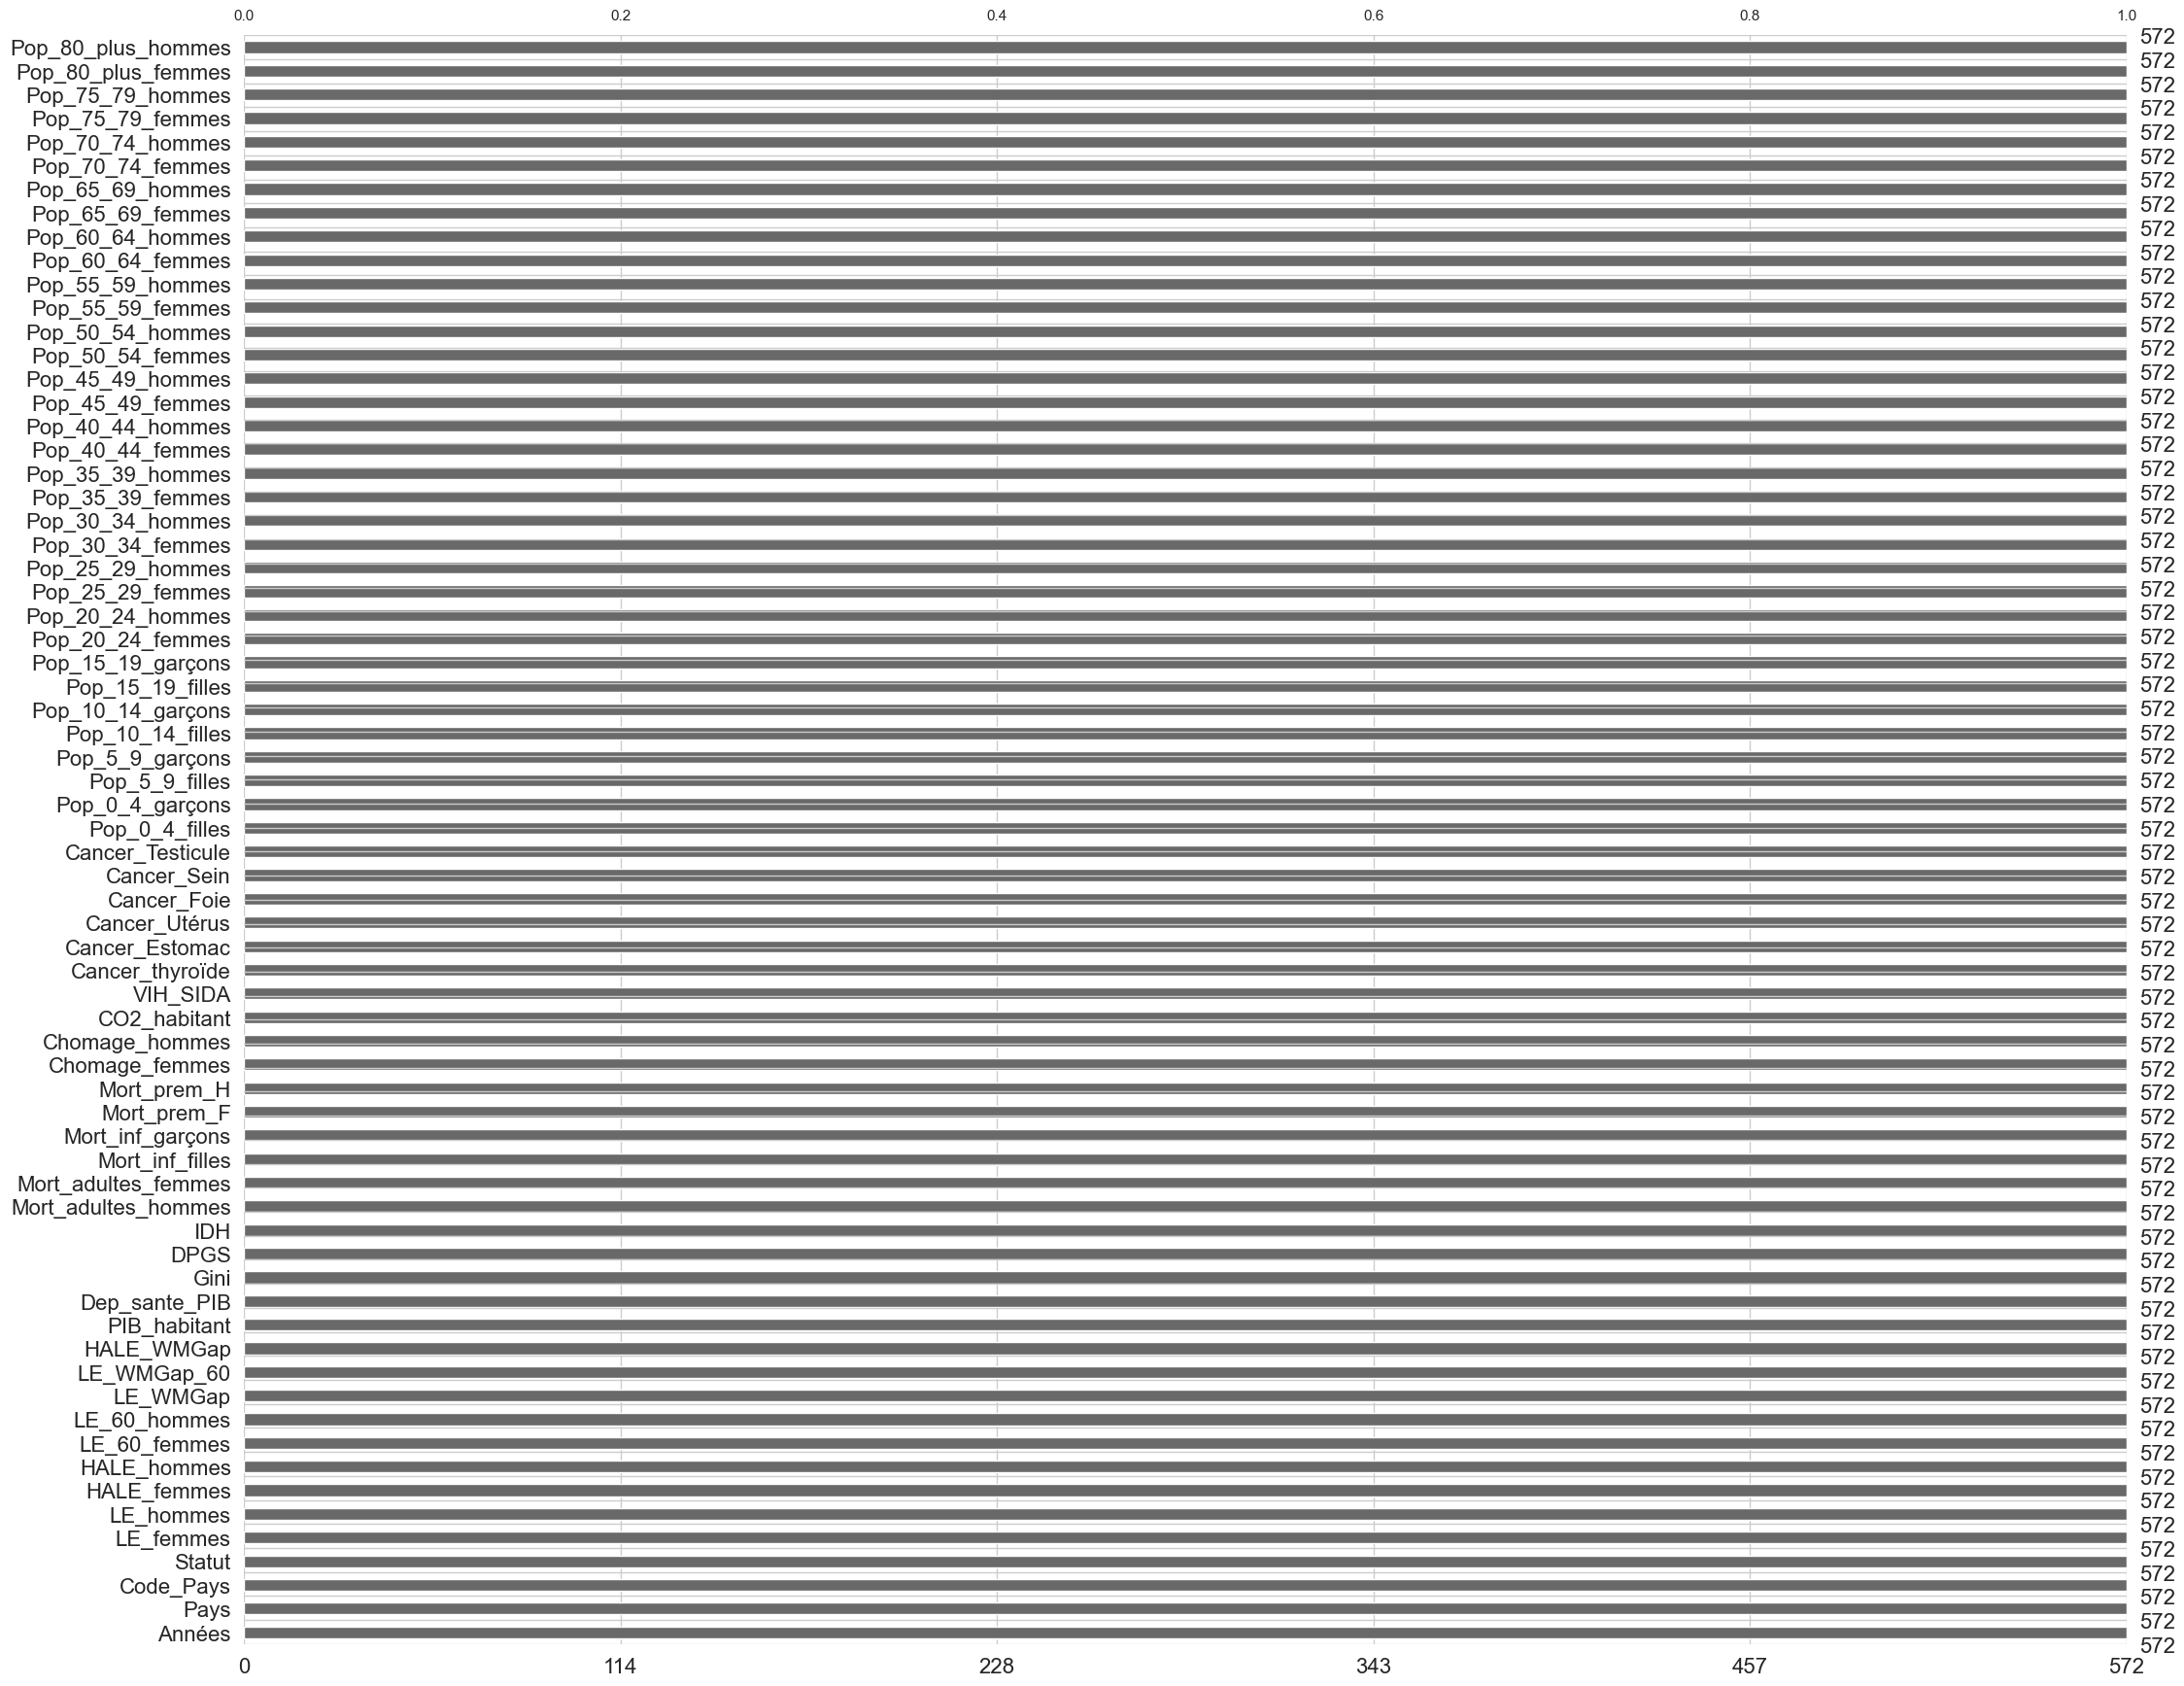

In [13]:
msno.bar(df)

# 4. EDA

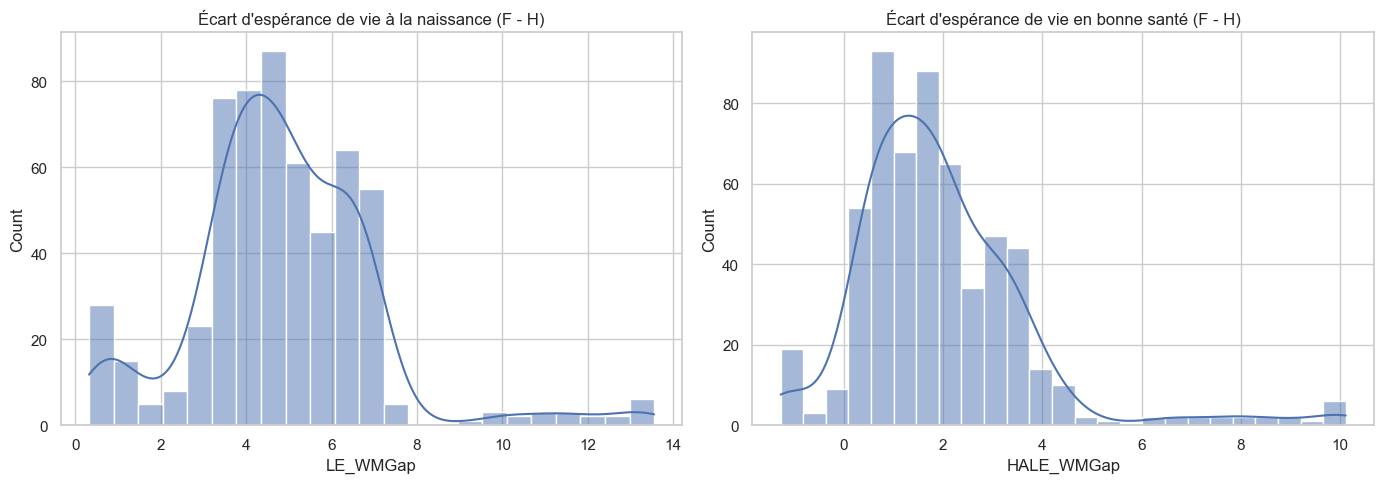

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["LE_WMGap"], kde=True, ax=axes[0])
axes[0].set_title("Écart d'espérance de vie à la naissance (F - H)")

sns.histplot(df["HALE_WMGap"], kde=True, ax=axes[1])
axes[1].set_title("Écart d'espérance de vie en bonne santé (F - H)")

plt.tight_layout()
plt.show()


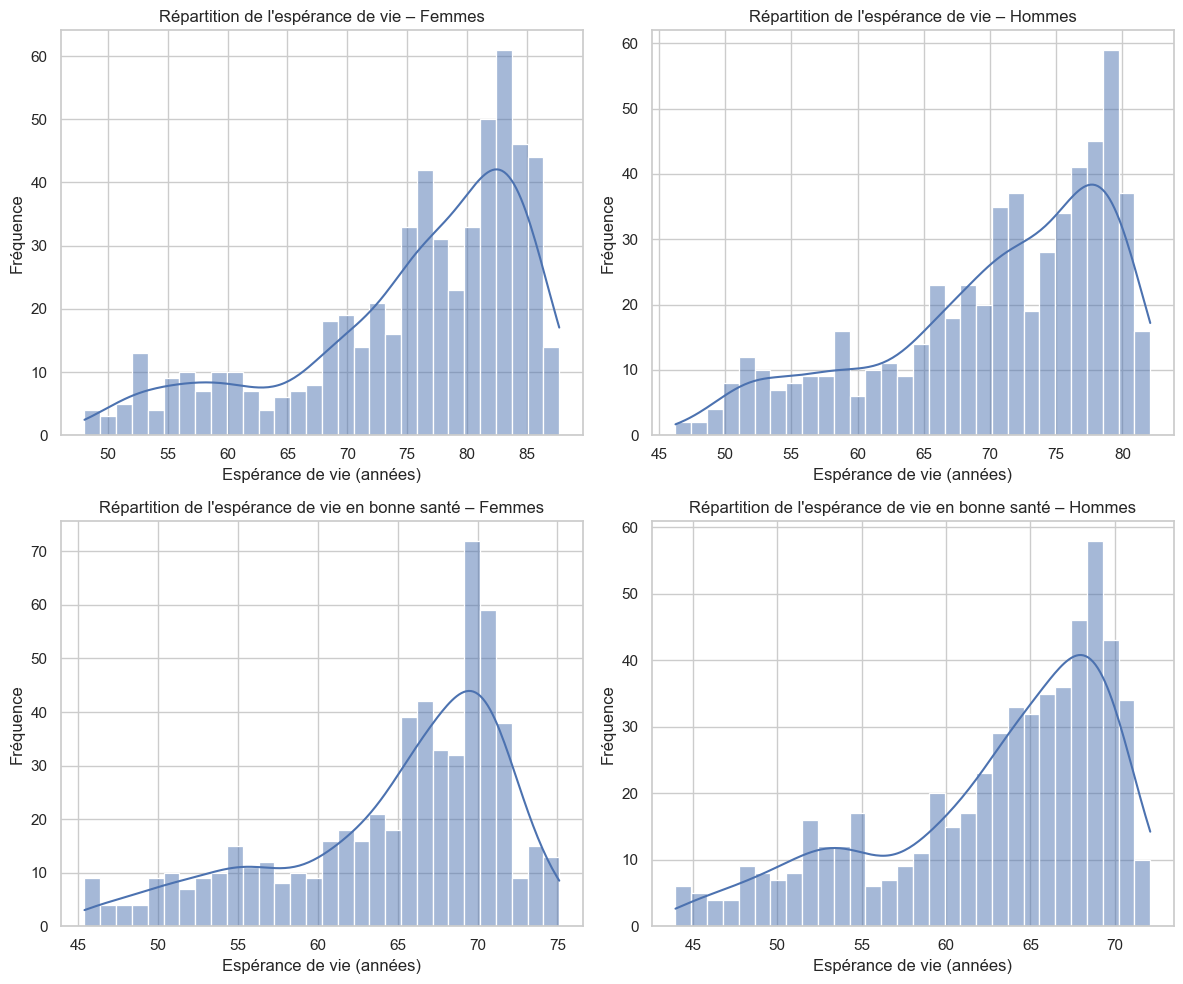

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


plots = [
    ('LE_femmes', "Répartition de l'espérance de vie – Femmes"),
    ('LE_hommes', "Répartition de l'espérance de vie – Hommes"),
    ('HALE_femmes', "Répartition de l'espérance de vie en bonne santé – Femmes"),
    ('HALE_hommes', "Répartition de l'espérance de vie en bonne santé – Hommes")
]

for ax, (var, titre) in zip(axes.flat, plots):
    sns.histplot(df[var].dropna(), kde=True, bins=30, ax=ax)
    ax.set_title(titre)
    ax.set_xlabel("Espérance de vie (années)")
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

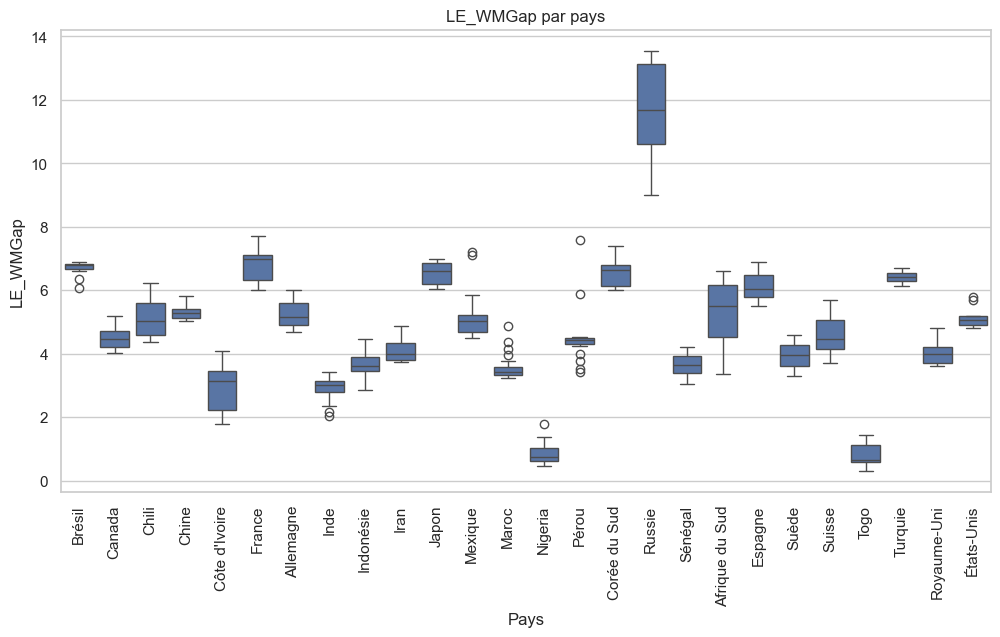

In [16]:
TARGET = "LE_WMGap"
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Pays", y=TARGET)
plt.xticks(rotation=90)
plt.title("LE_WMGap par pays")
plt.show()

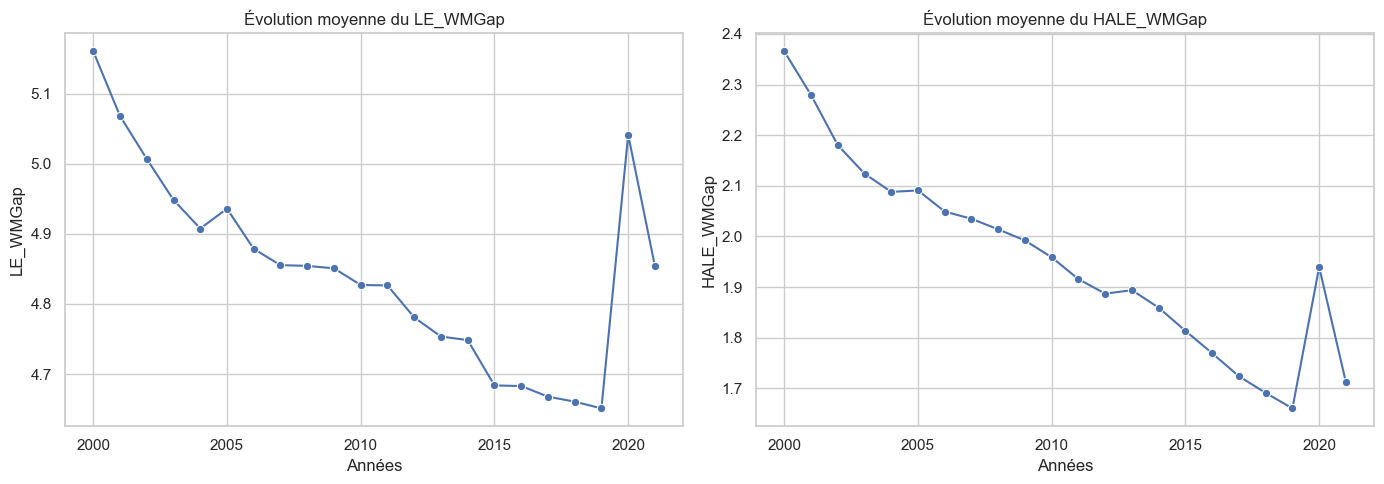

In [17]:
# Calcul des moyennes par année
mean_gap = df.groupby("Années")[["LE_WMGap", "HALE_WMGap"]].mean().reset_index()

# Création de la figure avec 2 graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphe 1 : LE_WMGap ---
sns.lineplot(
    data=mean_gap,
    x="Années",
    y="LE_WMGap",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Évolution moyenne du LE_WMGap")
axes[0].set_xlabel("Années")
axes[0].set_ylabel("LE_WMGap")

# --- Graphe 2 : HALE_WMGap ---
sns.lineplot(
    data=mean_gap,
    x="Années",
    y="HALE_WMGap",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Évolution moyenne du HALE_WMGap")
axes[1].set_xlabel("Années")
axes[1].set_ylabel("HALE_WMGap")

plt.tight_layout()
plt.show()


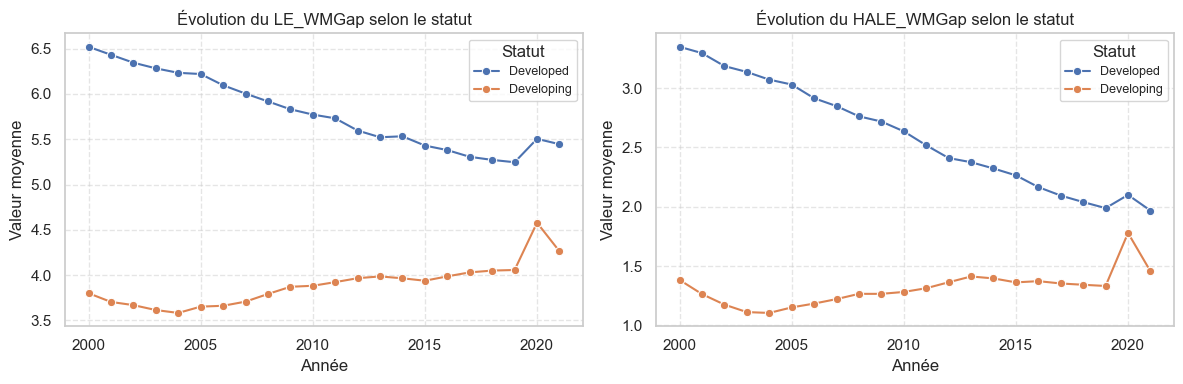

In [18]:
sns.set(style="whitegrid", context="notebook")

# --- Moyennes par année et par statut ---
mean_gap = (
    df.groupby(["Années", "Statut"])[["LE_WMGap", "HALE_WMGap"]]
      .mean()
      .reset_index()
)

# --- Création de la figure avec 2 graphiques côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- 1️⃣ LE_WPGap ---
sns.lineplot(
    data=mean_gap,
    x="Années",
    y="LE_WMGap",
    hue="Statut",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Évolution du LE_WMGap selon le statut")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Valeur moyenne")
axes[0].legend(title="Statut", fontsize=9)
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- 2️⃣ HALE_WMGap ---
sns.lineplot(
    data=mean_gap,
    x="Années",
    y="HALE_WMGap",
    hue="Statut",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Évolution du HALE_WMGap selon le statut")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Valeur moyenne")
axes[1].legend(title="Statut", fontsize=9)
axes[1].grid(True, linestyle="--", alpha=0.5)

# --- Ajustement ---
plt.tight_layout()
plt.show()

In [19]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="Code_Pays",
    color="LE_femmes",
    hover_name="Pays",
    hover_data={
        "LE_femmes": ":.1f",
        "LE_hommes": ":.1f",
    },
    color_continuous_scale=px.colors.sequential.Viridis,  # palette lisible et académique
    projection="natural earth",
    title="Espérance de vie moyenne H-F par pays"
)

# --- Amélioration du style ---
fig.update_layout(
    title_font_size=22,
    title_x=0.5,
    margin=dict(l=0, r=0, t=60, b=0),

    # 🌊 Océans et fond
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="white",
        showcountries=True,
        countrycolor="white",
        showocean=True,
        oceancolor="#A6CAE0",      # bleu doux pour les océans
        showland=True,
        landcolor="#F5F5F5",       # gris clair pour les terres
        lakecolor="#A6CAE0",
        bgcolor="white"
    ),

    # 🎚️ Barre de couleur
    coloraxis_colorbar=dict(
        title="Années",
        title_font_size=14,
        tickfont_size=12,
        len=0.75,
        thickness=15,
    )
)

fig.show()


## 4.2 Corrélations 

LE_WMGap               1.000000
Cancer_Estomac         0.623438
Cancer_Utérus          0.615525
Cancer_thyroïde        0.538235
DPGS                   0.533058
IDH                    0.512225
CO2_habitant           0.494832
Cancer_Testicule       0.328401
Cancer_Sein            0.312437
Dep_sante_PIB          0.230774
Mort_prem_H            0.204930
Chomage_hommes         0.191317
Chomage_femmes         0.170219
PIB_habitant           0.149291
Cancer_Foie            0.125042
Gini                   0.071892
Mort_adultes_hommes   -0.123139
VIH_SIDA              -0.204183
Mort_prem_F           -0.280740
Mort_adultes_femmes   -0.467985
Mort_inf_garçons      -0.603830
Mort_inf_filles       -0.611126
Name: LE_WMGap, dtype: float64

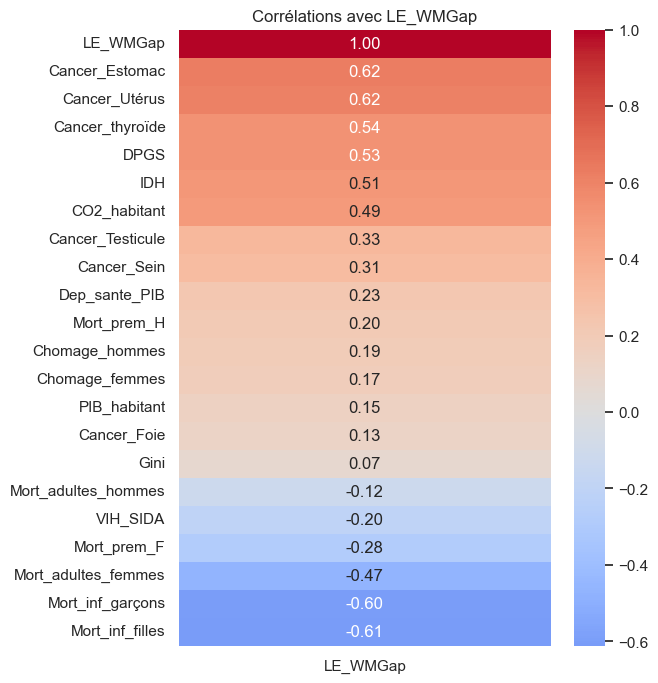

In [20]:
vars_selected = [
    "LE_WMGap",
    "Gini",
    "PIB_habitant",
    "DPGS",
    "Dep_sante_PIB",
    "IDH",
    'Mort_adultes_hommes',
    'Mort_adultes_femmes',
	'Mort_inf_filles',
    'Mort_inf_garçons',
    'Mort_prem_F',
	'Mort_prem_H',
	'Chomage_femmes',
    'Chomage_hommes',
     'CO2_habitant',
     'VIH_SIDA',
     'Cancer_thyroïde',
    'Cancer_Estomac',
    'Cancer_Utérus',
     'Cancer_Foie',
     'Cancer_Sein',
     'Cancer_Testicule',
]

num_df = df[vars_selected]

# Corrélations avec la cible
corr_target = num_df.corr()['LE_WMGap'].sort_values(ascending=False)

display(corr_target)

plt.figure(figsize=(6, 8))
sns.heatmap(
    corr_target.to_frame(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title(f"Corrélations avec {'LE_WMGap'}")
plt.show()

## 4.3 relations bivariées

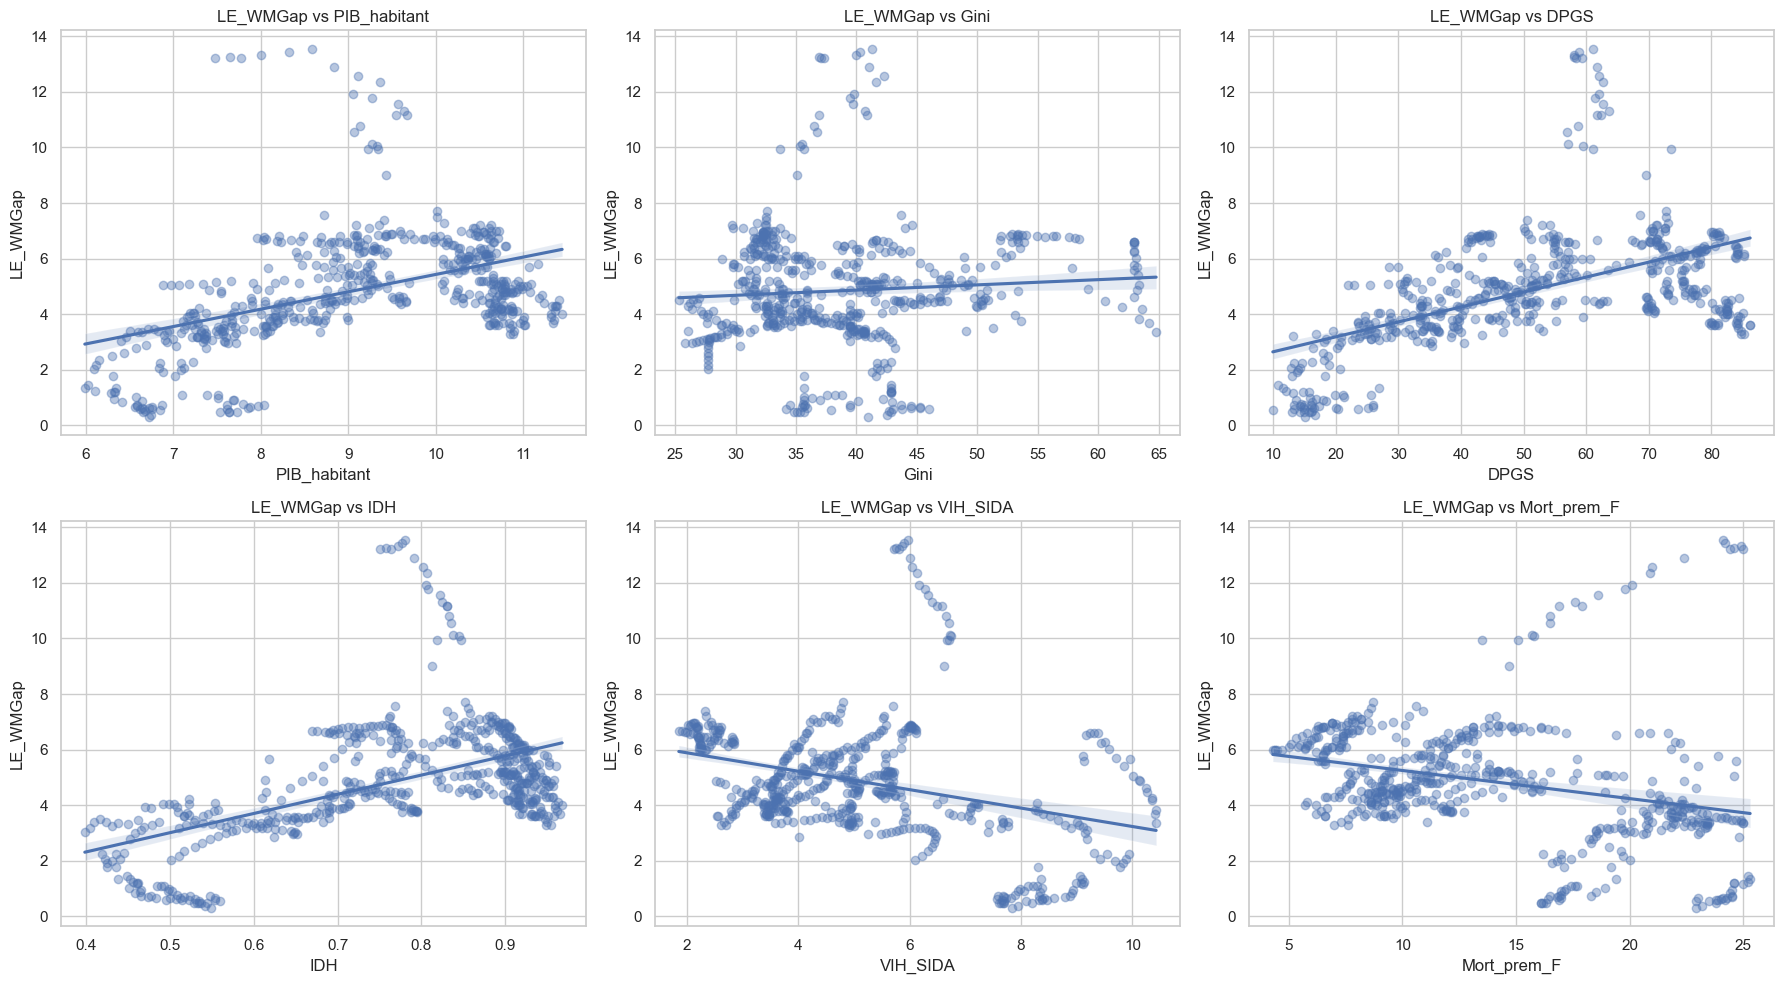

In [21]:
def regplot_safe(ax, x, y=TARGET, data=df, logx=False, title=None):
    tmp = data[[x, y]].copy()
    if logx:
        tmp[x] = np.log1p(tmp[x])
    sns.regplot(data=tmp, x=x, y=y, scatter_kws={"alpha":0.4}, ax=ax)
    ax.set_title(title if title else f"{y} vs {x}" + (" (log1p)" if logx else ""))

# Variables
vars_economiques = [("PIB_habitant", True), ("Gini", False), ("DPGS", False), ("IDH", False)]
vars_san_et_demo  = [("VIH_SIDA", True), ("Mort_prem_F", False), ("Mort_prem_H", False), ('CO2_habitant', True)]

all_vars = vars_economiques + vars_san_et_demo

# Création figure 2 lignes x 3 colonnes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # pour itérer facilement

for ax, (col, lg) in zip(axes, all_vars):
    if col in df.columns:
        regplot_safe(ax, x=col, logx=lg, title=f"{TARGET} vs {col}")

plt.tight_layout()
plt.show()

# 5. Préparation des données pour le Machine Learning

## 5.1 Définition de la cible et des variables explicatives

La variable cible du modèle est l’écart d’espérance de vie entre femmes et hommes `(LE_WMGap)`. Les variables explicatives retenues regroupent des indicateurs **socio-économiques, sanitaires, environnementaux et temporels**. Les identifiants **(pays, codes)**, les variables synthétiques catégorielles ainsi que les variables dérivées de la cible ont été exclues afin d’éviter toute fuite d’information et de garantir l’interprétabilité des modèles.

In [22]:
TARGET = "LE_WMGap"
ID_COLS = ["Pays", "Code_Pays", "Statut"]
TIME_COL = "Années"

X = df.drop(columns=[TARGET] + [c for c in ID_COLS if c in df.columns])
y = df[TARGET].copy()

In [23]:
# =========================
# 5.1 Cible et variables ML
# =========================

TARGET = "LE_WMGap"

features = [
    # Temps
    "Années",
    
    # Économie / inégalités
    "PIB_habitant",
    "Gini",
    "IDH",
    "Chomage_femmes",
    "Chomage_hommes",
    "CO2_habitant",
    
    # Système de santé
    "Dep_sante_PIB",
    "DPGS",
    
    # Santé & mortalité
    "Mort_adultes_hommes",
    "Mort_adultes_femmes",
    "Mort_inf_filles",
    "Mort_inf_garçons",
    "Mort_prem_F",
    "Mort_prem_H",
    "VIH_SIDA",
    
    # Pathologies (cancers)
    "Cancer_thyroïde",
    "Cancer_Estomac",
    "Cancer_Utérus",
    "Cancer_Foie",
    "Cancer_Sein",
    "Cancer_Testicule"
]

# Construction de X et y
X = df[features].copy()
y = df[TARGET].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)


Dimensions de X : (572, 22)
Dimensions de y : (572,)


## 5.2 Séparation temporelle des données (train / test)

Les données ont été séparées selon un critère temporel afin de reproduire une situation réaliste de prévision. Les observations couvrant la période 2000–2017 sont utilisées pour l’apprentissage des modèles, tandis que la période 2018–2021 est réservée à l’évaluation hors échantillon.

In [24]:
# =========================
# 5.2 Split temporel
# =========================

TIME_COL = "Années"
train_end = 2017

train_mask = df[TIME_COL] <= train_end
test_mask  = df[TIME_COL] > train_end

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_test  = X.loc[test_mask].copy()
y_test  = y.loc[test_mask].copy()

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (468, 22) (468,)
Test  : (104, 22) (104,)


## 5.3 Prétraitement : imputation et standardisation (PIPELINE)

Les variables explicatives sont imputées par la médiane afin de gérer les valeurs manquantes, puis standardisées pour garantir la comparabilité des échelles. Ces transformations sont intégrées dans un pipeline afin qu’elles soient estimées uniquement sur les données d’entraînement, évitant ainsi toute fuite d’information.

In [25]:
num_features = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features)
    ],
    remainder="drop"
)

# 6. Modélisation

## 6.1 Modèle de référence (Baseline)

La régression linéaire est utilisée comme modèle de référence afin d’évaluer les gains apportés par des modèles plus flexibles. Elle permet d’obtenir une première approximation des performances prédictives sur la période de test.

In [26]:
# Pipeline baseline
baseline_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

# Entraînement
baseline_pipe.fit(X_train, y_train)

# Prédictions
y_pred_base = baseline_pipe.predict(X_test)

# Évaluation
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("Baseline - Régression linéaire")
print(f"MAE  : {mae_base:.3f}")
print(f"RMSE : {rmse_base:.3f}")
print(f"R²   : {r2_base:.3f}")

Baseline - Régression linéaire
MAE  : 0.406
RMSE : 0.516
R²   : 0.924


## 6.2 Modèles Machine Learning

In [27]:
# =============================================
# 6.2 Entraînement et évaluation des modèles ML
# =============================================

models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results.append({
        "Modèle": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "pipe": pipe,
        "pred": y_pred
    })

results_df = pd.DataFrame([{k:v for k,v in r.items() if k in ["Modèle","MAE","RMSE","R2"]} for r in results]) \
             .sort_values(["RMSE","MAE"], ascending=True)

results_df

,Modèle,MAE,RMSE,R2
0,Ridge,0.455441,0.593523,0.898951
3,GradientBoosting,0.444610,0.608906,0.893645
1,ElasticNet,0.514940,0.681087,0.866935
2,RandomForest,0.539887,0.822444,0.805969


## 6.3 Sélection du meilleur modèle (règle RMSE + simplicité)

In [28]:
# Ajouter la baseline au même format
baseline_result = {
    "Modèle": "LinearRegression",
    "MAE": mae_base,
    "RMSE": rmse_base,
    "R2": r2_base,
    "pipe": baseline_pipe,
    "pred": y_pred_base
}

# Combiner baseline + autres modèles
all_results = [baseline_result] + results

all_results_df = pd.DataFrame([
    {k:v for k,v in r.items() if k in ["Modèle","MAE","RMSE","R2"]}
    for r in all_results
]).sort_values(["RMSE","MAE"], ascending=True)

display(all_results_df)

best_name = all_results_df.iloc[0]["Modèle"]
best = next(r for r in all_results if r["Modèle"] == best_name)

print("Modèle final retenu :", best["Modèle"])
best_pipe = best["pipe"]
best_pred = best["pred"]

,Modèle,MAE,RMSE,R2
0,LinearRegression,0.405947,0.516006,0.923622
1,Ridge,0.455441,0.593523,0.898951
4,GradientBoosting,0.444610,0.608906,0.893645
2,ElasticNet,0.514940,0.681087,0.866935
3,RandomForest,0.539887,0.822444,0.805969


Modèle final retenu : LinearRegression


## 6.4 Prévisions (observé vs prédit) + erreurs

In [29]:
pred_df = df.loc[test_mask, ["Pays", "Années"]].copy()
pred_df["y_true"] = y_test.values
pred_df["y_pred"] = best_pred
pred_df["error"] = pred_df["y_pred"] - pred_df["y_true"]

display(pred_df.head())


,Pays,Années,y_true,y_pred,error
18,Brésil,2018,6.612,6.415188,-0.196812
19,Brésil,2019,6.370,6.199973,-0.170027
20,Brésil,2020,6.062,6.178307,0.116307
21,Brésil,2021,6.591,6.194941,-0.396059
40,Canada,2018,4.200,4.382219,0.182219


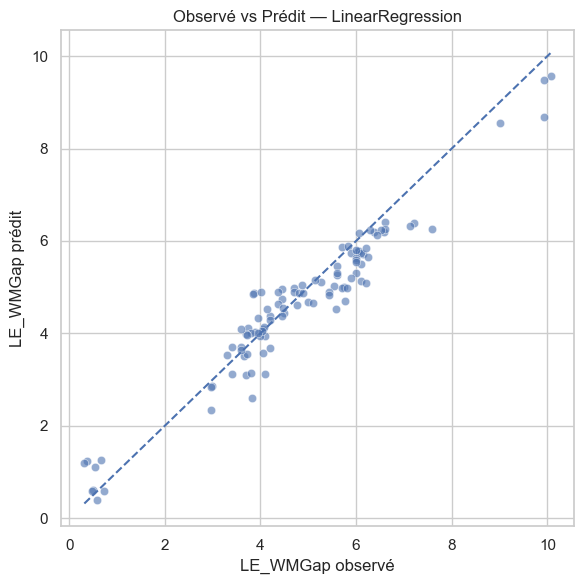

In [30]:
models_to_plot = {
    "LinearRegression": baseline_result
}

for name, res in models_to_plot.items():
    pred_df_tmp = df.loc[test_mask, ["Pays", "Années"]].copy()
    pred_df_tmp["y_true"] = y_test.values
    pred_df_tmp["y_pred"] = res["pred"]

    plt.figure(figsize=(6,6))
    sns.scatterplot(data=pred_df_tmp, x="y_true", y="y_pred", alpha=0.6)
    
    minv = min(pred_df_tmp["y_true"].min(), pred_df_tmp["y_pred"].min())
    maxv = max(pred_df_tmp["y_true"].max(), pred_df_tmp["y_pred"].max())
    plt.plot([minv, maxv], [minv, maxv], linestyle="--")

    plt.title(f"Observé vs Prédit — {name}")
    plt.xlabel("LE_WMGap observé")
    plt.ylabel("LE_WMGap prédit")
    plt.tight_layout()
    plt.show()


### 6.4.1 Observé vs prédit (global)

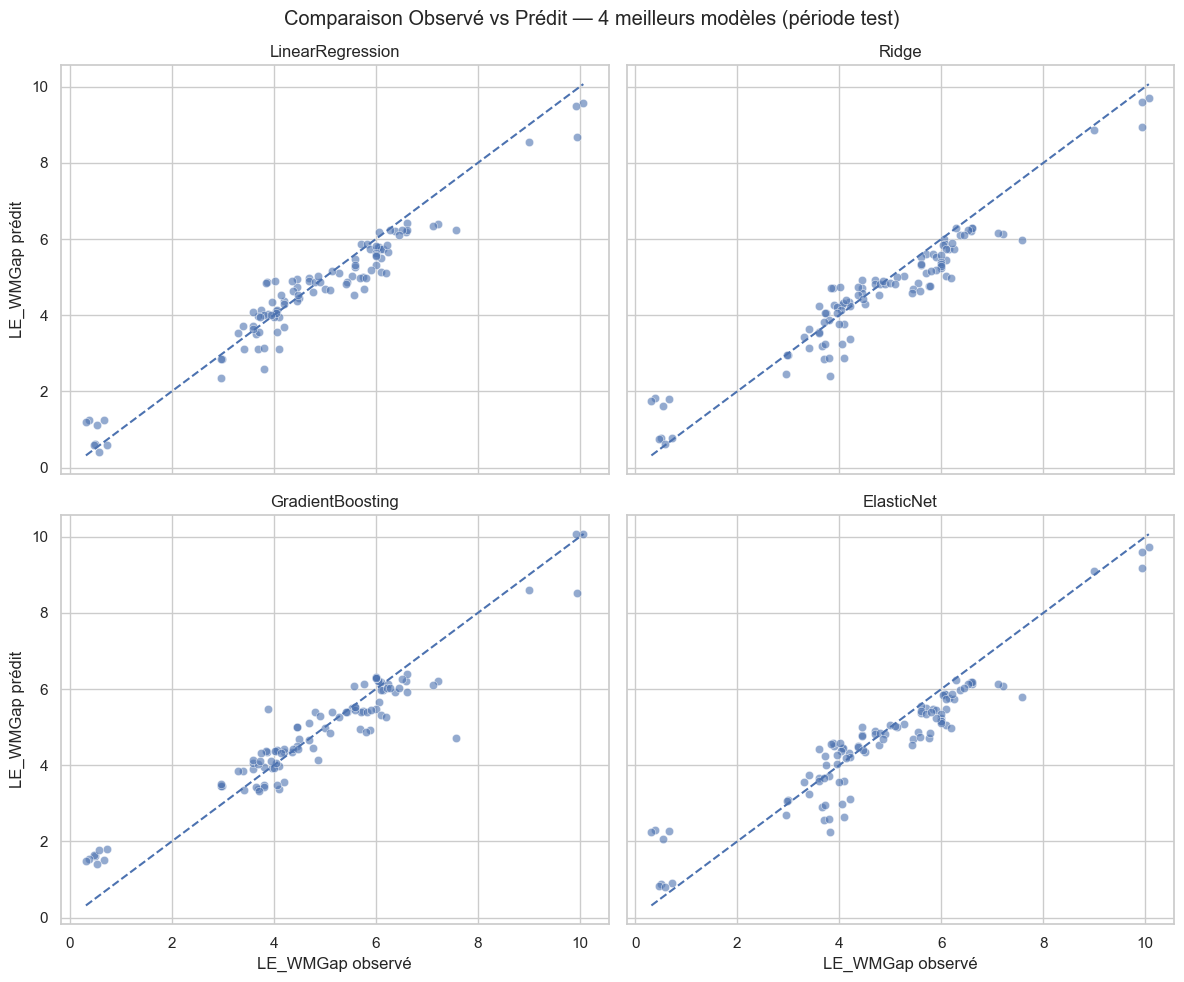

In [31]:
# Sélection des 4 meilleurs modèles
top_models = all_results_df.head(4)["Modèle"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, top_models):
    res = next(r for r in all_results if r["Modèle"] == model_name)

    tmp = df.loc[test_mask, ["Pays", "Années"]].copy()
    tmp["y_true"] = y_test.values
    tmp["y_pred"] = res["pred"]

    sns.scatterplot(
        data=tmp,
        x="y_true",
        y="y_pred",
        alpha=0.6,
        ax=ax
    )

    minv = min(tmp["y_true"].min(), tmp["y_pred"].min())
    maxv = max(tmp["y_true"].max(), tmp["y_pred"].max())
    ax.plot([minv, maxv], [minv, maxv], linestyle="--")

    ax.set_title(model_name)
    ax.set_xlabel("LE_WMGap observé")
    ax.set_ylabel("LE_WMGap prédit")

plt.suptitle("Comparaison Observé vs Prédit — 4 meilleurs modèles (période test)")
plt.tight_layout()
plt.show()





On compare les prédictions observé–prédit pour les quatre modèles les plus performants selon le `RMSE`. Tous les modèles présentent une dispersion relativement faible autour de la diagonale, confirmant de bonnes performances prédictives. **Le modèle linéaire** se distingue néanmoins par une concentration légèrement plus forte autour de la diagonale, en cohérence avec les métriques quantitatives, ce qui justifie son choix comme modèle final.

### 6.4.2 Erreur par pays (dispersion) 

,mean,std,count
Pays,,,
Pérou,-0.285412,0.715699,4
Mexique,-0.354813,0.528603,4
Afrique du Sud,-0.693162,0.428560,4
Russie,-0.657893,0.403445,4
Chili,0.166147,0.297175,4
Côte d'Ivoire,-0.860378,0.296902,4
Iran,0.816939,0.294638,4
Espagne,-0.367866,0.244647,4
États-Unis,-0.573156,0.233102,4


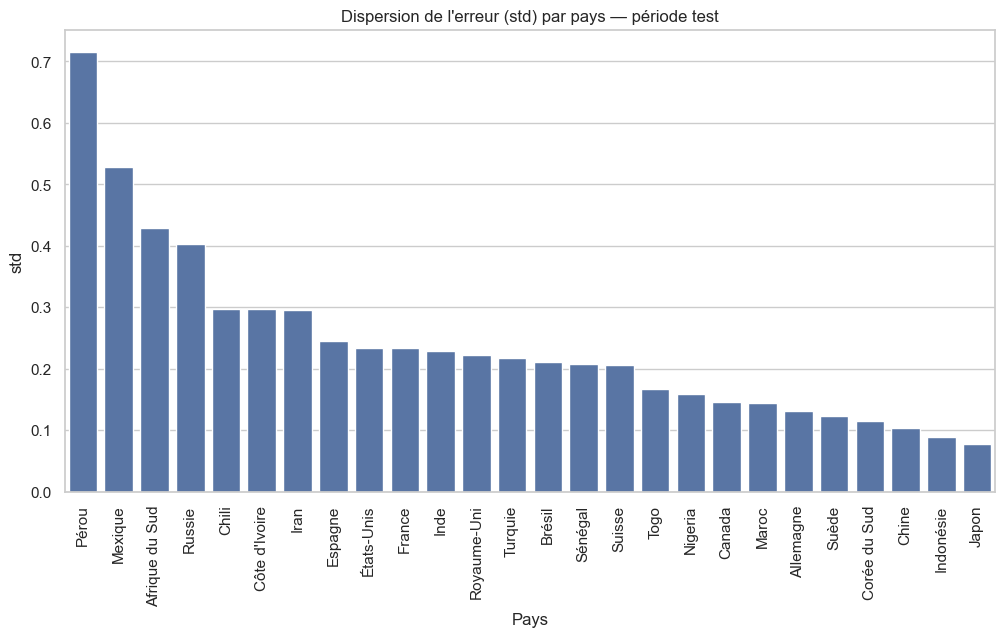

In [32]:
err_country = pred_df.groupby("Pays")["error"].agg(["mean","std","count"]).sort_values("std", ascending=False)
display(err_country.head(10))

plt.figure(figsize=(12,6))
sns.barplot(data=err_country.reset_index(), x="Pays", y="std")
plt.xticks(rotation=90)
plt.title("Dispersion de l'erreur (std) par pays — période test")
plt.show()

# 7. Interprétation des coeficients

Mort_adultes_femmes   -4.649856
Mort_inf_garçons       4.116667
Mort_adultes_hommes    3.661115
Mort_inf_filles       -3.647815
Mort_prem_F           -0.841042
Mort_prem_H            0.484342
Cancer_thyroïde        0.445686
Gini                   0.275316
Cancer_Sein            0.222272
VIH_SIDA               0.214417
Chomage_hommes         0.214312
IDH                   -0.182441
Cancer_Estomac         0.172400
Cancer_Foie            0.156431
Dep_sante_PIB         -0.142849
Cancer_Testicule      -0.110817
CO2_habitant           0.093596
DPGS                  -0.063709
Cancer_Utérus         -0.026687
Années                -0.014080
Chomage_femmes         0.011595
PIB_habitant          -0.001183
dtype: float64

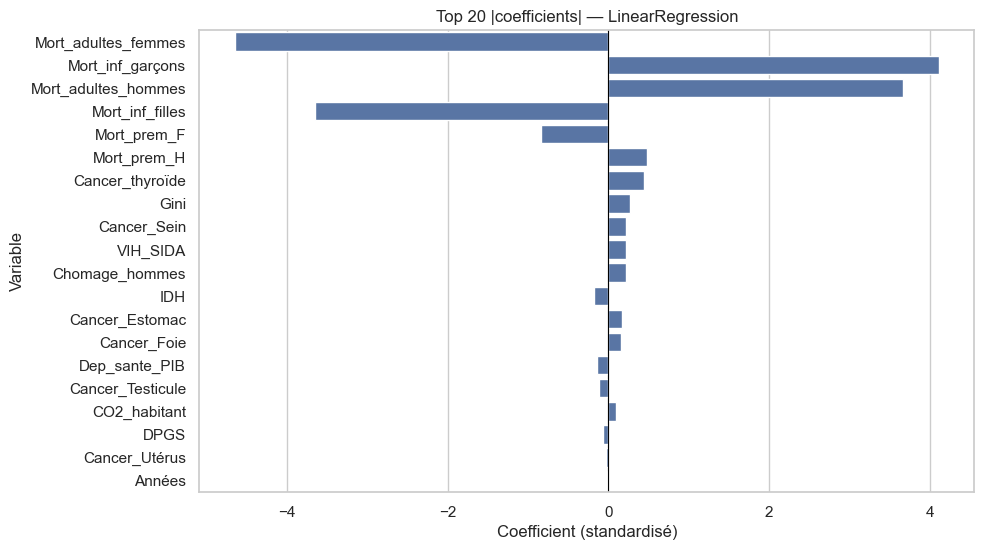

In [33]:
if best["Modèle"] in ["LinearRegression", "Ridge", "Lasso", "ElasticNet"]:
    model = best_pipe.named_steps["model"]
    coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
    display(coefs.head(25))

    plt.figure(figsize=(10,6))
    sns.barplot(x=coefs.head(20).values, y=coefs.head(20).index)
    plt.title(f"Top 20 |coefficients| — {best['Modèle']}")
    plt.xlabel("Coefficient (standardisé)")
    plt.ylabel("Variable")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.show()


# Clustering des pays

In [34]:
country_df = df.groupby("Pays")[features].median(numeric_only=True).reset_index()

country_features = country_df.drop(columns=["Pays"])

Xc = SimpleImputer(strategy="median").fit_transform(country_features)
Xc = StandardScaler().fit_transform(Xc)

scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Xc)
    scores[k] = silhouette_score(Xc, labels)

scores

{2: np.float64(0.3194492927571596),
 3: np.float64(0.26576167214389324),
 4: np.float64(0.280049321546972),
 5: np.float64(0.2830762979935206),
 6: np.float64(0.3025473899165948),
 7: np.float64(0.28761391595527364)}

In [36]:
# Clustering final avec k=2
k_final = 2
km = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
country_df["cluster"] = km.fit_predict(Xc)

country_df[["Pays", "cluster"]].sort_values("cluster")


,Pays,cluster
12,Iran,0
21,Suède,0
20,Suisse,0
19,Russie,0
18,Royaume-Uni,0
17,Pérou,0
15,Mexique,0
13,Japon,0
24,Turquie,0
25,États-Unis,0


In [37]:
cluster_profile = (
    country_df
    .groupby("cluster")
    .mean(numeric_only=True)
    .T
)

cluster_profile


cluster,0,1
Années,2010.500000,2010.500000
PIB_habitant,28214.175680,2450.505427
Gini,37.931944,40.666830
IDH,0.858361,0.563063
Chomage_femmes,7.859667,8.198937
Chomage_hommes,6.710833,7.520875
CO2_habitant,7.715172,1.873981
Dep_sante_PIB,8.262036,4.411490
DPGS,61.099828,28.250991
Mort_adultes_hommes,134.296861,301.672312


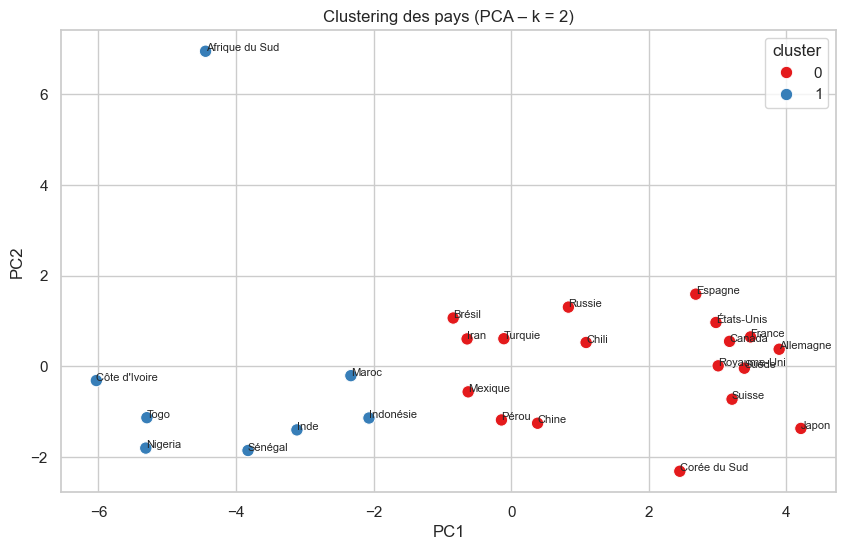

In [38]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xc)

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X2[:,0],
    y=X2[:,1],
    hue=country_df["cluster"],
    palette="Set1",
    s=80
)

for i, name in enumerate(country_df["Pays"]):
    plt.text(X2[i,0], X2[i,1], name, fontsize=8)

plt.title("Clustering des pays (PCA – k = 2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



Le clustering non supervisé met en évidence deux grands profils de pays. Le premier regroupe des pays caractérisés par un niveau de développement sanitaire et socio-économique relativement élevé, avec une mortalité plus faible et des dépenses de santé plus importantes. Le second cluster rassemble des pays faisant face à une charge sanitaire plus élevée, marquée par une mortalité prématurée importante et une prévalence accrue des maladies infectieuses. Cette typologie permet d’éclairer les différences observées dans l’écart d’espérance de vie entre femmes et hommes.

In [39]:
# Coefficients (loadings) des composantes principales
loadings = pd.DataFrame(
    pca.components_.T,
    index=country_features.columns,
    columns=["PC1", "PC2"]
)

# Trier par importance sur PC1
loadings_pc1 = loadings.sort_values(by="PC1", key=np.abs, ascending=False)

loadings_pc1.head(20)


,PC1,PC2
IDH,0.303296,0.081837
Mort_inf_garçons,-0.295386,-0.084800
Mort_inf_filles,-0.294355,-0.084885
Mort_adultes_femmes,-0.281164,0.090135
Mort_prem_F,-0.274973,0.039484
Mort_adultes_hommes,-0.263070,0.176442
DPGS,0.257004,0.145599
PIB_habitant,0.254714,0.024359
Cancer_thyroïde,0.251188,-0.015420
Dep_sante_PIB,0.233190,0.195284


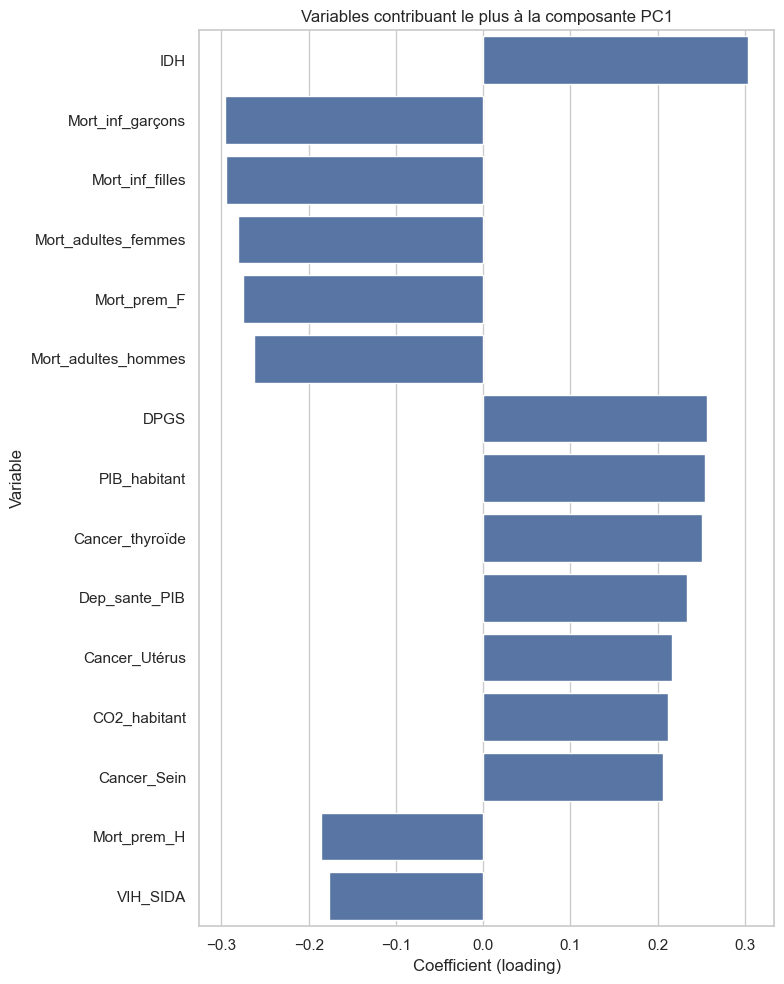

In [40]:
plt.figure(figsize=(8,10))
sns.barplot(
    x=loadings_pc1["PC1"].head(15),
    y=loadings_pc1.index[:15]
)
plt.title("Variables contribuant le plus à la composante PC1")
plt.xlabel("Coefficient (loading)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


# 7.1 Comparaison de LE_WMGap entre clusters

🎯 **Objectif**

Vérifier si les profils de pays identifiés présentent :
- des niveaux différents d’écart d’espérance de vie femmes–hommes
- une dispersion différente de cet écart

# 7.1.1 Fusionner les clusters avec les données annuelles

In [37]:
# Fusion cluster -> données annuelles
df_clustered = df.merge(
    country_df[["Pays", "cluster"]],
    on="Pays",
    how="left"
)

df_clustered[["Pays", "cluster"]].drop_duplicates().sort_values("cluster")


,Pays,cluster
0,Brésil,0
506,Turquie,0
462,Suisse,0
440,Suède,0
418,Espagne,0
352,Russie,0
330,Corée du Sud,0
308,Pérou,0
528,Royaume-Uni,0
242,Mexique,0


### 7.1.2 Statistiques descriptives de LE_WMGap par cluster

In [38]:
cluster_stats = (
    df_clustered
    .groupby("cluster")["LE_WMGap"]
    .agg(["mean", "median", "std", "min", "max"])
)

cluster_stats


,mean,median,std,min,max
cluster,,,,,
0,5.686412,5.2120,1.819799,3.300,13.55
1,2.959847,3.3175,1.511285,0.317,6.61


L’analyse descriptive met en évidence une différence nette de l’écart d’espérance de vie entre les deux clusters. Les pays du cluster à profil sanitaire consolidé présentent un écart moyen d’environ 5,7 années, contre seulement 3 années pour les pays du cluster à forte charge sanitaire. Ce résultat s’explique par une mortalité masculine plus tardive mais différenciée dans les pays les plus avancés, tandis que dans les pays à forte vulnérabilité sanitaire, la mortalité élevée affecte plus uniformément les deux sexes, réduisant mécaniquement l’écart d’espérance de vie.

### 7.1.3 Boxplot 

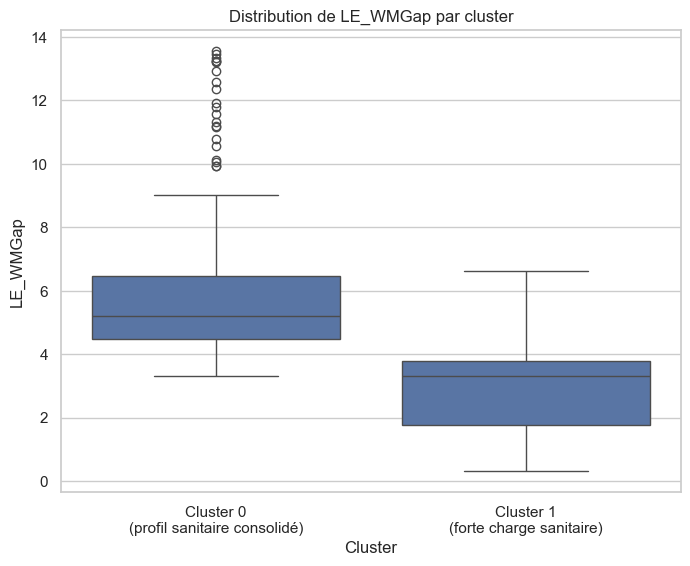

In [39]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_clustered,
    x="cluster",
    y="LE_WMGap"
)

plt.xticks([0,1], [
    "Cluster 0\n(profil sanitaire consolidé)",
    "Cluster 1\n(forte charge sanitaire)"
])

plt.title("Distribution de LE_WMGap par cluster")
plt.xlabel("Cluster")
plt.ylabel("LE_WMGap")
plt.show()


### 7.1.4 Évolution temporelle de LE_WMGap par cluster

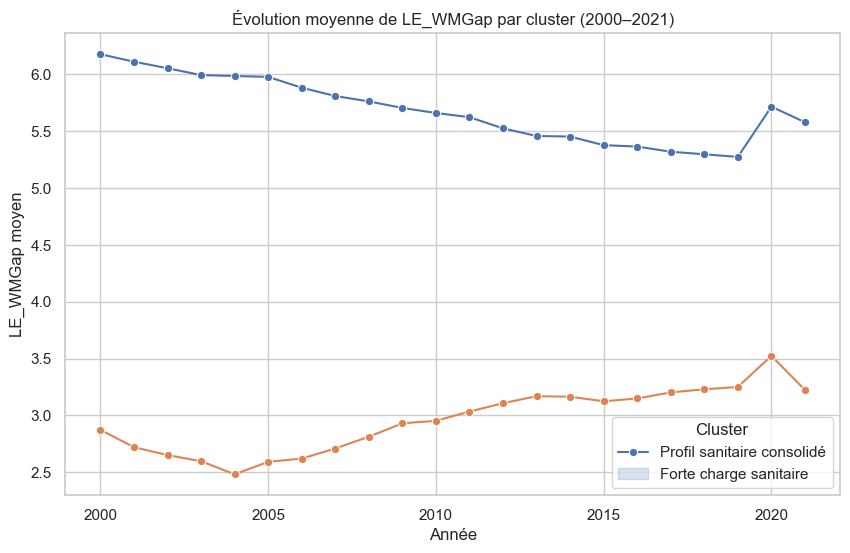

In [40]:
mean_gap_cluster = (
    df_clustered
    .groupby(["Années", "cluster"])["LE_WMGap"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=mean_gap_cluster,
    x="Années",
    y="LE_WMGap",
    hue="cluster",
    marker="o"
)

plt.title("Évolution moyenne de LE_WMGap par cluster (2000–2021)")
plt.xlabel("Année")
plt.ylabel("LE_WMGap moyen")
plt.legend(
    title="Cluster",
    labels=[
        "Profil sanitaire consolidé",
        "Forte charge sanitaire"
    ]
)
plt.show()

# 8. Conclusion 

Cette étude combine une approche de **Machine Learning supervisée et non supervisée** pour analyser les déterminants de `l’écart d’espérance de vie entre femmes et hommes dans 26 pays sur la période 2000–2021`. Les résultats montrent que des *modèles simples et interprétables offrent d’excellentes performances prédictives*. Les déterminants clés identifiés — mortalité, dépenses publiques de santé et maladies infectieuses — structurent également une typologie claire des pays, distinguant des profils sanitaires contrastés. L’ensemble des résultats est cohérent et robuste, confirmant le rôle central des facteurs sanitaires et socio-économiques dans la compréhension des inégalités de mortalité entre les sexes.